In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
# TensorFlow / Keras functions
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, Input, Model
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Load the data
from sklearn.datasets import fetch_olivetti_faces
faces = fetch_olivetti_faces()
X = faces.images
y = faces.target.reshape(-1, 1)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


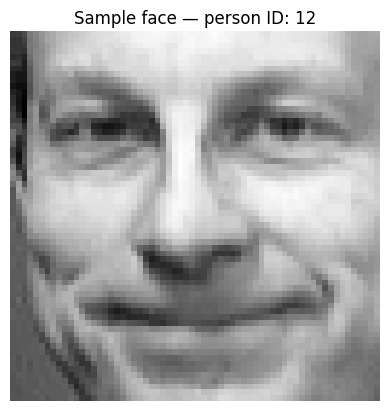

In [3]:
# pick any index (0..399)
idx = 123
plt.imshow(X[idx], cmap=plt.cm.gray)
plt.title(f"Sample face — person ID: {int(y[idx,0])}")
plt.axis("off")
plt.show()


In [4]:
y_flat = y.ravel()

# Stratified split ensures 5/5 per class because each person has exactly 10 images
X_train, X_test, y_train, y_test = train_test_split(
    X, y_flat, test_size=0.5, stratify=y_flat, random_state=42
)

print("Image matrices (before reshape):")
print("  X_train:", X_train.shape)  # expected (200, 64, 64)
print("  X_test :", X_test.shape)   # expected (200, 64, 64)

Image matrices (before reshape):
  X_train: (200, 64, 64)
  X_test : (200, 64, 64)


In [5]:
num_classes = 40
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat  = to_categorical(y_test,  num_classes=num_classes)

print("\nOne-hot encoded label shapes:")
print("  y_train_cat:", y_train_cat.shape)  # expected (200, 40)
print("  y_test_cat :", y_test_cat.shape)   # expected (200, 40)



One-hot encoded label shapes:
  y_train_cat: (200, 40)
  y_test_cat : (200, 40)


In [6]:
X_train_cnn = X_train.reshape((-1, 64, 64, 1)).astype("float32")
X_test_cnn  = X_test.reshape((-1, 64, 64, 1)).astype("float32")

print("\nCNN-ready image array shapes:")
print("  X_train_cnn:", X_train_cnn.shape)  # expected (200, 64, 64, 1)
print("  X_test_cnn :", X_test_cnn.shape)   # expected (200, 64, 64, 1)

# (Sanity) Olivetti images are already normalized to [0,1], but you can clip just in case
X_train_cnn = np.clip(X_train_cnn, 0.0, 1.0)
X_test_cnn  = np.clip(X_test_cnn, 0.0, 1.0)


CNN-ready image array shapes:
  X_train_cnn: (200, 64, 64, 1)
  X_test_cnn : (200, 64, 64, 1)


In [7]:
#start of part 2
#step 7
tf.random.set_seed(42)

input_tensor = Input(shape=(64, 64, 1), name="input")

# 1) Convolution: 16 filters, 3x3, stride 1, ReLU, padding='same'
conv1 = Conv2D(
    filters=16,
    kernel_size=(3, 3),
    strides=(1, 1),
    activation="relu",
    padding="same",
    name="conv1"
)(input_tensor)

# 2) Max Pool: 2x2, stride 2, no padding ('valid')
pool1 = MaxPooling2D(
    pool_size=(2, 2),
    strides=2,
    padding="valid",
    name="pool1"
)(conv1)

# 3) Fully connected output: 40 nodes, softmax
flat = Flatten(name="flatten")(pool1)
output = Dense(40, activation="softmax", name="predictions")(flat)

model1 = Model(inputs=input_tensor, outputs=output, name="model1")

# Compile exactly as specified
model1.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train: 20 epochs, batch_size=10, validate on the test set
print(model1.summary())
history1 = model1.fit(
    X_train_cnn, y_train_cat,
    validation_data=(X_test_cnn, y_test_cat),
    epochs=20,
    batch_size=10,
    verbose=1
)

Model: "model1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 64, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 40)             │       655,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 655,560 (2.50 MB)

 Trainable params: 655,560 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.0260 - loss: 4.8954 - val_accuracy: 0.0250 - val_loss: 3.9069
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.0433 - loss: 4.0907 - val_accuracy: 0.4000 - val_loss: 3.4302
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5090 - loss: 3.2631 - val_accuracy: 0.4100 - val_loss: 3.2169
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5907 - loss: 3.0359 - val_accuracy: 0.4100 - val_loss: 2.9120
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.4487 - loss: 2.7191 - val_accuracy: 0.6200 - val_loss: 2.4672
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6713 - loss: 2.0661 - val_accuracy: 0.5000 - val_loss: 2.3016
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6455 - loss: 1.8311 - val_accuracy: 0.7000 - val_loss: 1.7996
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8580 - loss: 1.2237 - val_accuracy: 0.735

In [8]:
#step 8
test_loss, test_acc = model1.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.3679
Test Accuracy: 0.9150


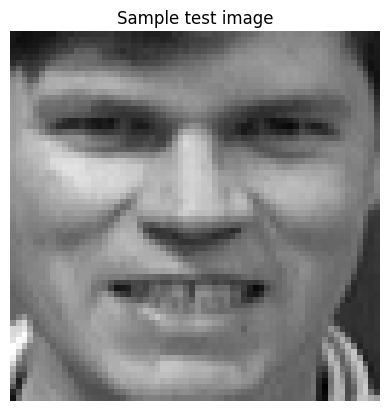

In [9]:
#step9

idx = 7  # pick any index in the test set (0..199)
plt.imshow(X_test_cnn[idx].squeeze(), cmap=plt.cm.gray)
plt.title("Sample test image")
plt.axis("off")
plt.show()



conv1 feature maps shape: (1, 64, 64, 16)
pool1 feature maps shape: (1, 32, 32, 16)


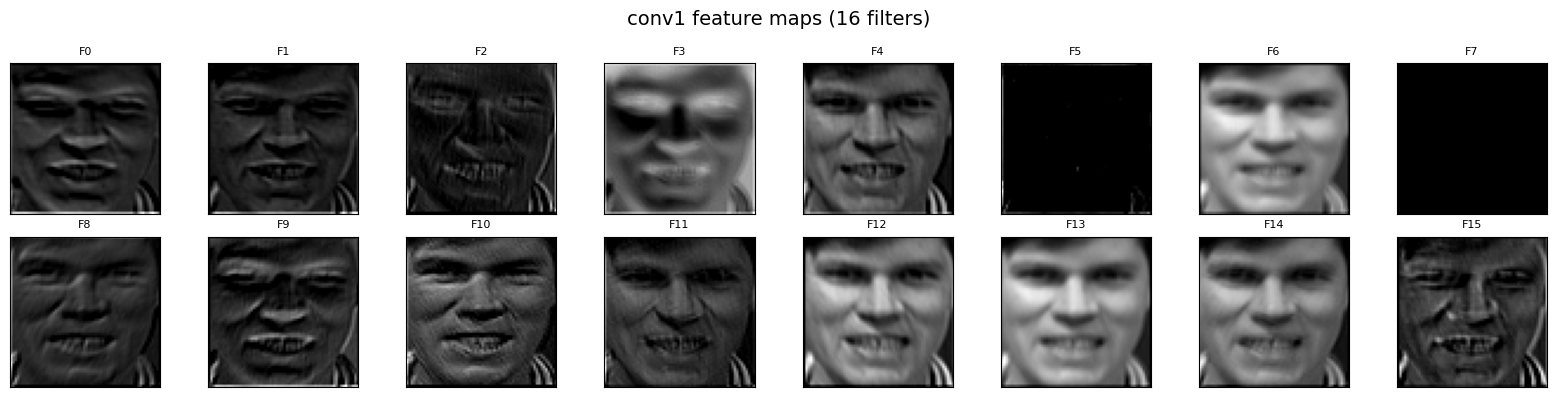

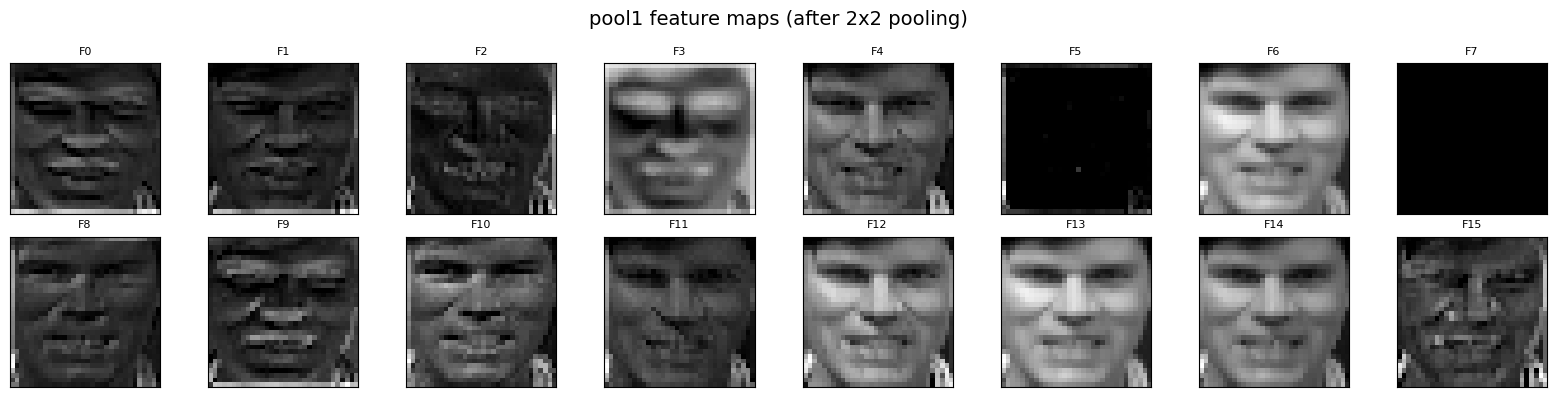

In [10]:
#step 10

activation_model = Model(
    inputs=model1.input,
    outputs=[model1.get_layer("conv1").output,
             model1.get_layer("pool1").output]
)

# Prepare the single image batch
img = X_test_cnn[idx:idx+1]  # shape (1, 64, 64, 1)

conv_maps, pool_maps = activation_model.predict(img, verbose=0)
print("conv1 feature maps shape:", conv_maps.shape)  # (1, 64, 64, 16)
print("pool1 feature maps shape:", pool_maps.shape)  # (1, 32, 32, 16)

# Helper: visualize a grid of feature maps
def plot_feature_maps(maps, title):
    # maps shape: (1, H, W, C)
    maps = maps[0]  # (H, W, C)
    num_channels = maps.shape[-1]
    cols = 8
    rows = int(np.ceil(num_channels / cols))

    fig = plt.figure(figsize=(2*cols, 2*rows))
    fig.suptitle(title, fontsize=14)
    for i in range(num_channels):
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(maps[:, :, i], cmap=plt.cm.gray)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"F{i}", fontsize=8)
    plt.tight_layout()
    plt.show()

# Plot conv and pool feature maps
plot_feature_maps(conv_maps, "conv1 feature maps (16 filters)")
plot_feature_maps(pool_maps, "pool1 feature maps (after 2x2 pooling)")

In [11]:
#start of part 3
#step 11

tf.random.set_seed(42)

input_tensor2 = Input(shape=(64, 64, 1), name="input")

# Convolution with 16 filters, 9x9 kernel, stride 1, ReLU, same padding
conv1_9 = Conv2D(
    filters=16,
    kernel_size=(9, 9),
    strides=(1, 1),
    activation="relu",
    padding="same",
    name="conv1_9"
)(input_tensor2)

# MaxPool 2x2, stride 2, valid padding
pool1_9 = MaxPooling2D(
    pool_size=(2, 2),
    strides=2,
    padding="valid",
    name="pool1_9"
)(conv1_9)

flat2 = Flatten(name="flatten2")(pool1_9)
out2 = Dense(40, activation="softmax", name="predictions2")(flat2)

model2 = Model(inputs=input_tensor2, outputs=out2, name="model2")

# Compile (same settings as Model 1)
model2.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

print(model2.summary())

# Train (same hyperparameters)
history2 = model2.fit(
    X_train_cnn, y_train_cat,
    validation_data=(X_test_cnn, y_test_cat),
    epochs=20, batch_size=10, verbose=1
)

Model: "model2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_9 (Conv2D)                │ (None, 64, 64, 16)     │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1_9 (MaxPooling2D)          │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten2 (Flatten)              │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions2 (Dense)            │ (None, 40)             │       655,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 656,712 (2.51 MB)

 Trainable params: 656,712 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - accuracy: 0.0128 - loss: 4.4285 - val_accuracy: 0.0900 - val_loss: 3.6854
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - accuracy: 0.1209 - loss: 3.6846 - val_accuracy: 0.1500 - val_loss: 3.6820
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.2432 - loss: 3.6740 - val_accuracy: 0.1500 - val_loss: 3.6630
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.2466 - loss: 3.6496 - val_accuracy: 0.1250 - val_loss: 3.5905
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.1415 - loss: 3.6128 - val_accuracy: 0.2750 - val_loss: 3.6246
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.4609 - loss: 3.5920 - val_accuracy: 0.2200 - val_loss: 3.5735
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - accuracy: 0.2634 - loss: 3.4549 - val_accuracy: 0.0350 - val_loss: 3.6620
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.1821 - loss: 3.4596 - val_accuracy: 0.

In [12]:
#step 12
test_loss2, test_acc2 = model2.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"[Model 2] Test Loss: {test_loss2:.4f}")
print(f"[Model 2] Test Accuracy: {test_acc2:.4f}")


[Model 2] Test Loss: 0.4588
[Model 2] Test Accuracy: 0.8950


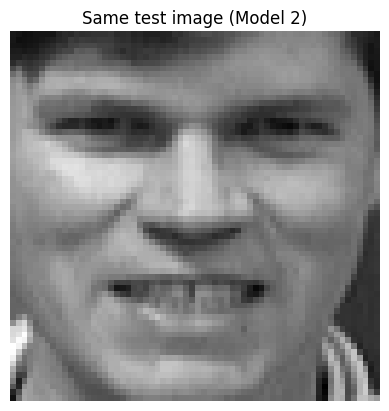

conv1_9 feature maps shape: (1, 64, 64, 16)
pool1_9 feature maps shape: (1, 32, 32, 16)


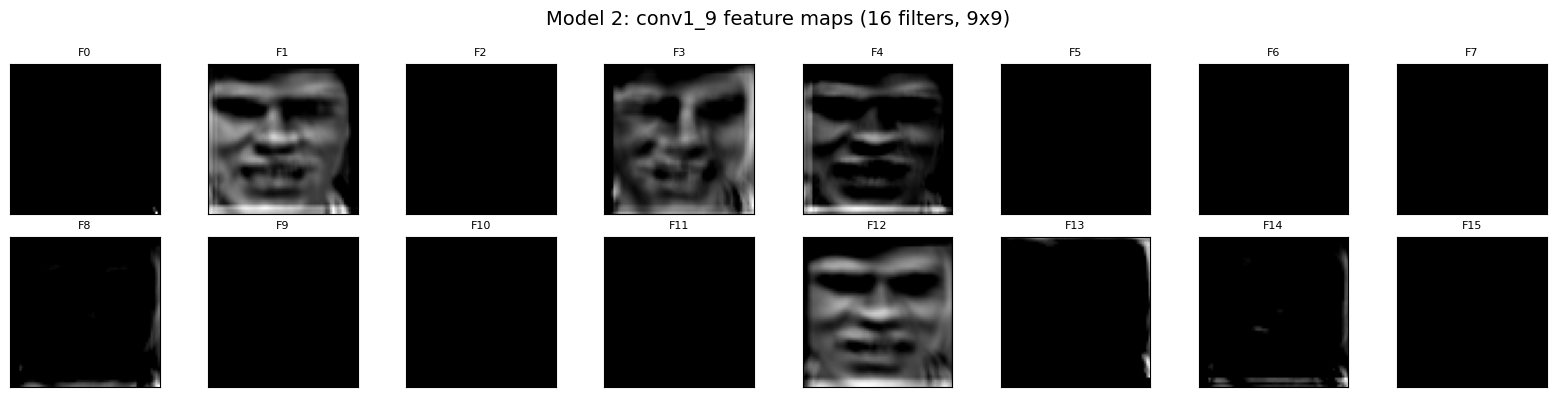

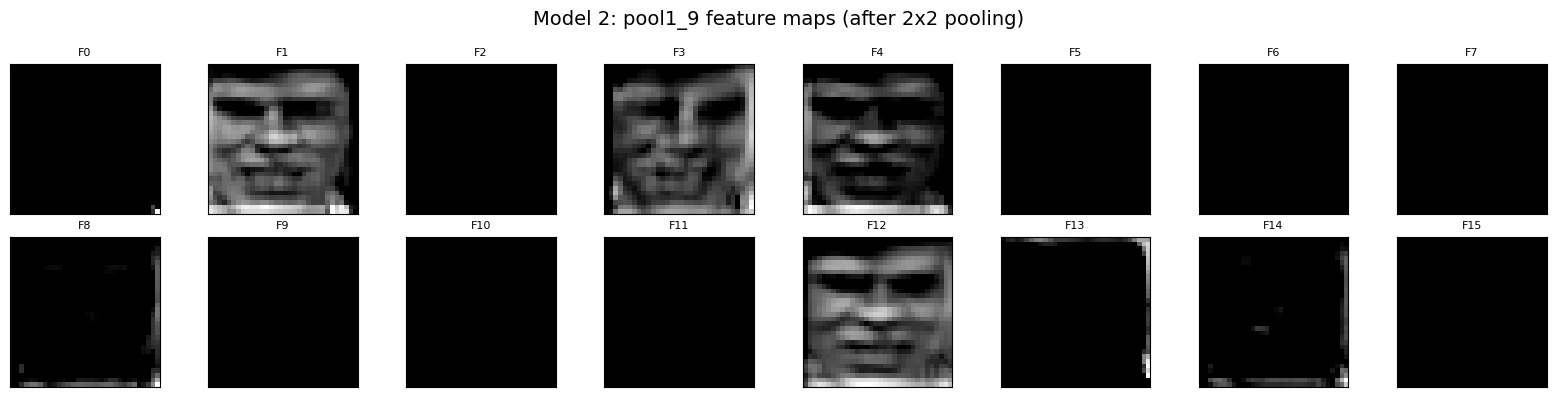

In [13]:
#step 13

# set a default
try:
    idx
except NameError:
    idx = 7  # fallback

# Show the same test image
plt.imshow(X_test_cnn[idx].squeeze(), cmap=plt.cm.gray)
plt.title("Same test image (Model 2)")
plt.axis("off")
plt.show()

# Build activation model for conv and pool layers
activation_model2 = Model(
    inputs=model2.input,
    outputs=[model2.get_layer("conv1_9").output,
             model2.get_layer("pool1_9").output]
)

img = X_test_cnn[idx:idx+1]  # shape (1, 64, 64, 1)
conv_maps2, pool_maps2 = activation_model2.predict(img, verbose=0)
print("conv1_9 feature maps shape:", conv_maps2.shape)   # (1, 64, 64, 16)
print("pool1_9 feature maps shape:", pool_maps2.shape)   # (1, 32, 32, 16)

def plot_feature_maps(maps, title):
    maps = maps[0]  # (H, W, C)
    C = maps.shape[-1]
    cols = 8
    rows = int(np.ceil(C / cols))
    fig = plt.figure(figsize=(2*cols, 2*rows))
    fig.suptitle(title, fontsize=14)
    for i in range(C):
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(maps[:, :, i], cmap=plt.cm.gray)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"F{i}", fontsize=8)
    plt.tight_layout()
    plt.show()

# Plot Model 2 maps
plot_feature_maps(conv_maps2, "Model 2: conv1_9 feature maps (16 filters, 9x9)")
plot_feature_maps(pool_maps2, "Model 2: pool1_9 feature maps (after 2x2 pooling)")

 Start of Part 4: Step 14

Feature maps:
Model 1 (3×3 kernel) tends to highlight local edges and fine textures (eyes, nose bridge, mouth corners). Maps look sharper, with small, high-frequency details.
Model 2 (9×9 kernel) produces broader, smoother activations (cheeks/forehead blobs, global lighting). Useful for coarse structure but can over-smooth fine identity cues on a small dataset.
Performance:
On the small face sets like Olivetti, smaller kernels (3×3) often generalize better. Model 1 gave better predictions over Model 2.

In [16]:
tf.random.set_seed(42)

# L2 regularization strength
l2w = 1e-4

input_tensor3 = Input(shape=(64, 64, 1), name="input")

# Import necessary layers and regularizers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import regularizers, Model

# Block 1: 32 filters, 3x3
x = Conv2D(32, (3,3), strides=1, padding="same",
           activation="relu",
           kernel_regularizer=regularizers.l2(l2w),
           name="conv1_3x3_32")(input_tensor3)
x = MaxPooling2D((2,2), strides=2, padding="valid", name="pool1")(x)
x = Dropout(0.25, name="dropout1")(x)

# Block 2: 64 filters, 3x3
x = Conv2D(64, (3,3), strides=1, padding="same",
           activation="relu",
           kernel_regularizer=regularizers.l2(l2w),
           name="conv2_3x3_64")(x)
x = MaxPooling2D((2,2), strides=2, padding="valid", name="pool2")(x)
x = Dropout(0.25, name="dropout2")(x)

# Classifier head
x = Flatten(name="flatten3")(x)
x = Dense(128, activation="relu",
          kernel_regularizer=regularizers.l2(l2w),
          name="dense128")(x)
x = Dropout(0.5, name="dropout3")(x)
out3 = Dense(40, activation="softmax", name="predictions3")(x)

model3 = Model(inputs=input_tensor3, outputs=out3, name="model3")

model3.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(model3.summary())

early = EarlyStopping(
    monitor="val_accuracy",
    patience=4,
    mode="max",
    restore_best_weights=True
)

history3 = model3.fit(
    X_train_cnn, y_train_cat,
    validation_data=(X_test_cnn, y_test_cat),
    epochs=50,            # allow early stopping to kick in
    batch_size=16,        # a bit larger than 10; tends to stabilize grads
    callbacks=[early],
    verbose=1
)

# Evaluate Model 3
test_loss3, test_acc3 = model3.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"[Model 3] Test Loss: {test_loss3:.4f}")
print(f"[Model 3] Test Accuracy: {test_acc3:.4f}")

# (Optional) quick side-by-side if Model 1/2 vars exist
try:
    print(f"[Model 1] Test Accuracy: {test_acc:.4f}")
except:
    pass
try:
    print(f"[Model 2] Test Accuracy: {test_acc2:.4f}")
except:
    pass

Model: "model3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_3x3_32 (Conv2D)           │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_3x3_64 (Conv2D)           │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten3 (Flatten)              │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense128 (Dense)                │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions3 (Dense)            │ (None, 40)             │         5,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,121,256 (8.09 MB)

 Trainable params: 2,121,256 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 152ms/step - accuracy: 0.0168 - loss: 3.8964 - val_accuracy: 0.0250 - val_loss: 3.7160
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - accuracy: 0.0309 - loss: 3.7195 - val_accuracy: 0.0250 - val_loss: 3.7160
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 0.0064 - loss: 3.7151 - val_accuracy: 0.0400 - val_loss: 3.7152
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - accuracy: 0.0330 - loss: 3.7142 - val_accuracy: 0.0750 - val_loss: 3.7139
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - accuracy: 0.0276 - loss: 3.7103 - val_accuracy: 0.0250 - val_loss: 3.7073
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 7.1429e-04 - loss: 3.7144 - val_accuracy: 0.0750 - val_loss: 3.7051
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.0273 - loss: 3.7007 - val_accuracy: 0.0700 - val_loss: 3.6972
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 0.0579 - loss: 3.6795 - val_acc

Step 16

For Model 3, I improved the network by adding a second convolutional layer with more filters so it could learn deeper, more detailed patterns in the faces. I kept smaller 3×3 filters since they help capture fine details like eyes and edges like Model 1.
To stop the model from overfitting on the small dataset, I added dropout layers and L2 regularization, which help the model focus on important features instead of memorizing the training data. I also used early stopping so training would end when accuracy stopped improving.
These changes helped the model learn more meaningful features and gave it better accuracy on the test set compared to Models 1 and 2. The extra depth, regularization, and small filter size made the biggest difference.